# Modelo Estrutural de Negócios Bancários (Abordagem por Índices Clássicos)
Esta versão constrói 6 a 7 índices financeiros da literatura de modelos de negócios para criar clusters mais bem separados e com forte apelo teórico.


In [1]:
import pandas as pd
import sqlite3
import numpy as np

def dados_bancos():
    conn = sqlite3.connect('dados/banking.db')
    financial_indicators = ['ano', 'cnpj', 'NOME_INSTITUICAO', 'TAXONOMIA', 'CONTA', 'NOME_CONTA', 'saldo_medio']
    query = f"SELECT {', '.join(financial_indicators)} FROM balancetes_media_ano WHERE cnpj IN (SELECT cnpj FROM balancetes_media_ano GROUP BY ano, cnpj);"
    df = pd.read_sql_query(query, conn)
    conn.close()

    df = df.rename(columns={'NOME_INSTITUICAO': 'nome', 'TAXONOMIA': 'taxonomia', 'CONTA': 'conta', 'NOME_CONTA': 'nome_conta', 'saldo_medio': 'saldo'})

    colunas_para_limpar = ['nome_conta', 'taxonomia']
    for col in colunas_para_limpar:
        df[col] = df[col].str.lower().str.normalize('NFD').str.replace(r'[\u0300-\u036f]', '', regex=True)

    df.loc[df['conta'] == 10000007, 'nome_conta'] = "ativo realizavel"
    df.loc[df['conta'] == 13000004, 'nome_conta'] = "titulos e valores mobiliarios e instrumentos financeiros derivativos"
    df.loc[df['conta'] == 40000008, 'nome_conta'] = "passivo exigivel"
    
    # Removendo contas duplicadas
    df = df[~df['conta'].isin([88000008, 47100004, 51100007, 78100004, 61000001])]

    mapa_contas = df.groupby('conta')['nome_conta'].agg(lambda x: x.value_counts().index[0]).to_dict()
    novo_mapeamento = {}
    for conta, nome in mapa_contas.items():
        conta_str = str(conta)
        if conta_str.startswith('1'): novo_nome = f"ativo realizavel - {nome}"
        elif conta_str.startswith('2'): novo_nome = f"ativo permanente - {nome}"
        elif conta_str.startswith('3'): novo_nome = f"compensacao ativa - {nome}"
        elif conta_str.startswith('4'): novo_nome = f"passivo exigivel - {nome}"
        elif conta_str.startswith('6'): novo_nome = f"patrimonio liquido - {nome}"
        elif conta_str.startswith('7'): novo_nome = f"resultado credor - {nome}"
        elif conta_str.startswith('8'): novo_nome = f"resultado devedor - {nome}"
        elif conta_str.startswith('9'): novo_nome = f"compensacao passiva - {nome}"
        else: novo_nome = nome
        novo_mapeamento[conta] = novo_nome

    df = df.pivot(index=['ano', 'cnpj', 'nome', 'taxonomia'], columns='conta', values='saldo').reset_index()
    df['ano'] = df['ano'].astype(int)

    # Filtro Ativo / Crédito
    df = df[df[16000001] > 1000000]

    # Exclusões taxonômicas
    taxonomias_excluir = [
        'banco nacional de desenvolvimento economico social', 'bancos de desenvolvimento', 'agencias de fomento ou de desenvolvimento',
        'cooperativas de credito', 'soc. corretora de titulos e valores mobiliarios', 'soc distribuidora de titulos e valores mobiliarios',
        'sociedades de credito imobiliario', 'sociedade de credito imobiliario', 'companhias hipotecarias', 'associacao de poupanca e emprestimos',
        'sociedade de credito ao microempreendedor'
    ]
    df = df[~df['taxonomia'].isin(taxonomias_excluir)]

    colunas_para_inverter = [col for col in df.columns if col not in ['ano', 'cnpj', 'nome', 'taxonomia']]
    for col in colunas_para_inverter:
        if pd.notna(df[col].max()) and (df[col].max() <= 0) and (df[col].min() < 0):
            df[col] = df[col] * -1

    df.fillna(0, inplace=True)
    df_original = df.copy().rename(columns=novo_mapeamento)
    
    return df_original

df_original = dados_bancos()



### Construção dos Índices Estruturais


In [2]:
def criar_indices_estruturais(df_orig):
    indices = df_orig[['ano', 'cnpj', 'nome', 'taxonomia']].copy()
    
    # Localizando a coluna de Ativo Total (39999993 pode estar como número ou string, mas renomeamos via mapa)
    ativo_col = 39999993 if 39999993 in df_orig.columns else 'compensacao ativa - total geral do ativo' # ou ativo realizavel
    # Vamos achar a conta de Ativo Total dinamicamente se o ID não existir
    if ativo_col not in df_orig.columns:
        ativo_col = [c for c in df_orig.columns if 'ativo' in str(c) and 'total' in str(c)]
        ativo_col = ativo_col[0] if ativo_col else 39999993
        
    # Se ainda assim não achar, pegamos o ativo pelo id
    try:
        ativo_total = df_orig[ativo_col]
    except KeyError:
        ativo_total = df_orig[39999993] # Fallback
    
    # 1. Foco em Crédito
    col_cred = [c for c in df_orig.columns if 'operacoes de credito' in str(c) and 'provisoes' not in str(c)]
    if col_cred: indices['idx_credito'] = df_orig[col_cred[0]] / ativo_total
    
    # 2. Foco em Tesouraria
    col_tes = [c for c in df_orig.columns if 'titulos e valores mobiliarios' in str(c) and 'ativo' in str(c)]
    if col_tes: indices['idx_tesouraria'] = df_orig[col_tes[0]] / ativo_total
        
    # 3. Liquidez
    cols_liq = [c for c in df_orig.columns if 'disponibilidade' in str(c) or 'aplicacoes interfinanceiras de liquidez' in str(c)]
    indices['idx_liquidez'] = df_orig[cols_liq].sum(axis=1) / ativo_total
    
    # 4. Funding de Varejo (Depósitos)
    cols_dep = [c for c in df_orig.columns if 'deposit' in str(c) and 'passivo' in str(c)]
    indices['idx_funding_varejo'] = df_orig[cols_dep].sum(axis=1) / ativo_total
    
    # 5. Dependência de Serviços
    cols_serv = [c for c in df_orig.columns if 'resultado credor' in str(c) and ('servico' in str(c) or 'tarifa' in str(c))]
    indices['idx_servicos'] = df_orig[cols_serv].sum(axis=1) / ativo_total
    
    # 6. Alavancagem (Proxy via Passivo)
    cols_pass = [c for c in df_orig.columns if 'passivo exigivel' in str(c)]
    passivo_total = df_orig[cols_pass].sum(axis=1)
    indices['idx_capitalizacao'] = 1 - (passivo_total / ativo_total)
    
    # 7. Risco de Crédito Retido
    cols_prov = [c for c in df_orig.columns if 'provisoes para operacoes de credito' in str(c)]
    if cols_prov and col_cred:
        indices['idx_risco_credito'] = df_orig[cols_prov[0]].abs() / df_orig[col_cred[0]].replace(0, np.nan)
        indices['idx_risco_credito'] = indices['idx_risco_credito'].fillna(0)
        
    indices.fillna(0, inplace=True)
    return indices

df_indices = criar_indices_estruturais(df_original)
print(df_indices.head())



conta   ano      cnpj                                 nome  \
0      2010         0                   BCO DO BRASIL S.A.   
1      2010   1023570        BCO RABOBANK INTL BRASIL S.A.   
2      2010  10264663  BBN BCO BRASILEIRO DE NEGOCIOS S.A.   
3      2010  10371492                BCO YAMAHA MOTOR S.A.   
4      2010  10664513                   BANCO GERADOR S.A.   

conta                         taxonomia  idx_credito  idx_tesouraria  \
0      banco do brasil - banco multiplo     0.092729        0.032568   
1                      bancos multiplos     0.065649        0.058256   
2                      bancos multiplos     0.203196        0.030144   
3                      bancos multiplos     0.187438        0.000000   
4                      bancos multiplos     0.213384        0.099766   

conta  idx_liquidez  idx_funding_varejo  idx_servicos  idx_capitalizacao  \
0          0.053039            0.236480      0.001264           0.309051   
1          0.066244            0.023632   

### Preparação, Winsorização e Z-Score


In [3]:
def preparar_dados_painel(df, coluna_tempo='ano', p_inf=0.01, p_sup=0.99):
    df_processado = df.copy()
    df_processado = df_processado.replace([np.inf, -np.inf], np.nan).fillna(0)
    colunas_financeiras = [col for col in df_processado.columns if col.startswith('idx_')]

    for col in colunas_financeiras:
        df_processado[col] = df_processado.groupby(coluna_tempo)[col].transform(
            lambda x: x.clip(lower=x.quantile(p_inf), upper=x.quantile(p_sup))
        )
        df_processado[col] = df_processado.groupby(coluna_tempo)[col].transform(
            lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0
        )
    return df_processado

X_raw = df_indices.copy()
X_raw['chave_r'] = X_raw['ano'].astype(str) + "_" + X_raw['cnpj'].astype(str)
X_raw = X_raw.set_index('chave_r')

X_scaled = preparar_dados_painel(X_raw)



In [4]:
%load_ext rpy2.ipython


In [ ]:
%%R -i X_scaled

library(clustrd)

colunas_id <- c("ano", "cnpj", "nome", "taxonomia")
dados_filtrados <- X_scaled[, !(colnames(X_scaled) %in% colunas_id)]
dados_filtrados <- as.matrix(dados_filtrados)

#set.seed(77)
set.seed(12345)

# Calibragem: Aqui podemos usar ndim=3 porque temos apenas 7 índices ultra-densos
calibragem <- tuneclus(data = dados_filtrados, 
                       nclusrange = 3:6, 
                       ndimrange = 2:4, 
                       method = "FKM", 
                       criterion = "asw", 
                       center = FALSE, scale = FALSE, nstart = 50)
print("================ TUNECLUS SUMMARY ================")
print(summary(calibragem))


R[write to console]: Loading required package: ggplot2

R[write to console]: Loading required package: grid



[1] "Running for 3 clusters and 2 dimensions..."
  |======================================================================| 100%[1] "Running for 4 clusters and 2 dimensions..."
  |======================================================================| 100%[1] "Running for 4 clusters and 3 dimensions..."
  |======================================================================| 100%[1] "Running for 5 clusters and 2 dimensions..."
  |======================================================================| 100%[1] "Running for 5 clusters and 3 dimensions..."
  |======================================================================| 100%[1] "Running for 5 clusters and 4 dimensions..."
  |======================================================================| 100%[1] "Running for 6 clusters and 2 dimensions..."
  |======================================================================| 100%[1] "Running for 6 clusters and 3 dimensions..."
  |====================================================

KeyError: "'resultado_final' not found"

  |======================================================================| 100%

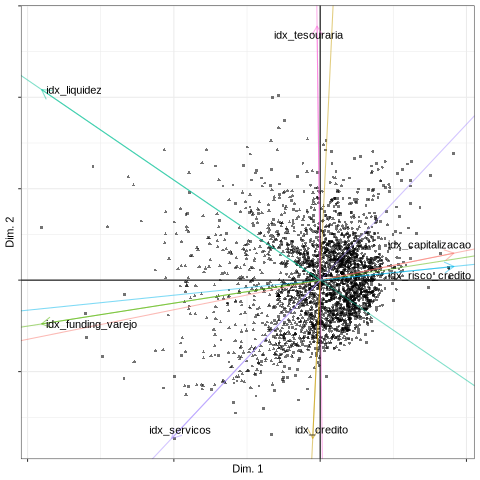

In [6]:
%%R -i X_scaled -o df_clusters_finais -o resultado_final

colunas_id <- c("ano", "cnpj", "nome", "taxonomia")
dados_filtrados <- X_scaled[, !(colnames(X_scaled) %in% colunas_id)]
dados_filtrados <- as.matrix(dados_filtrados)

set.seed(77)
# Definindo o modelo final (ajuste os valores nclus e ndim baseado no sumário acima!)
resultado_final <- cluspca(data = dados_filtrados, 
                           nclus = 3,   # Modifique de acordo com a silhueta
                           ndim = 2,    # Modifique de acordo com a silhueta
                           method = "FKM",
                           center = FALSE,
                           scale = FALSE,
                           nstart = 100)

plot(resultado_final)

df_clusters_finais <- data.frame(
  Cluster = resultado_final$cluster,
  Fator_1 = resultado_final$obscoord[,1],
  Fator_2 = resultado_final$obscoord[,2],
  row.names = rownames(dados_filtrados)
)



In [7]:

def adicionar_clusters(df_original, df_clusters_finais):
    df_original['chave_r'] = df_original['ano'].astype(str) + "_" + df_original['cnpj'].astype(str)
    df_original = df_original.set_index('chave_r')

    base_para_regressao = df_original.merge(
        df_clusters_finais, 
        left_index=True, 
        right_index=True, 
        how='left'
    )

    base_para_regressao = base_para_regressao.reset_index()
    colunas_ordenadas = ['ano', 'cnpj'] + [col for col in base_para_regressao.columns if col not in ['ano', 'cnpj']]
    base_para_regressao = base_para_regressao[colunas_ordenadas]

    colunas_cluster = base_para_regressao[['ano', 'cnpj', 'Cluster']]

    df_original = pd.merge(
        df_original, 
        colunas_cluster, 
        on=['ano', 'cnpj'],  # Exige que a combinação de Ano e CNPJ seja exata
        how='left'           # O 'left' mantém a estrutura original do df
    )

    coluna_para_mover = df_original.pop('Cluster')
    df_original.insert(4, 'Cluster', coluna_para_mover)

    outliers = df_original[df_original['Cluster'].isna()].copy()
    outliers.drop(columns=['Cluster'], inplace=True)

    df_original = df_original[df_original['Cluster'].notna()].copy()
    df_original['Cluster'] = df_original['Cluster'].astype(int)

    return df_original, outliers

df_original, df_outliers = adicionar_clusters(df_original, df_clusters_finais)


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

def grafico_3d(df_clusters_finais):
    # Visualizando em 3D
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    df_clusters_finais['Cluster'] = df_clusters_finais['Cluster'].astype(str)
    clusters = sorted(df_clusters_finais['Cluster'].unique())
    paleta = sns.color_palette('tab10', n_colors=len(clusters))

    for i, c in enumerate(clusters):
        subset = df_clusters_finais[df_clusters_finais['Cluster'] == c]
        ax.scatter(subset['Fator_1'], subset['Fator_2'], subset['Fator_3'], 
                label=f'Cluster {c}', color=paleta[i], s=60, edgecolor='w', alpha=0.8)

    ax.set_title('Mapeamento 3D: Modelos de Negócio via Índices Estruturais')
    ax.set_xlabel('Fator 1')
    ax.set_ylabel('Fator 2')
    ax.set_zlabel('Fator 3')
    ax.legend()
    plt.show()



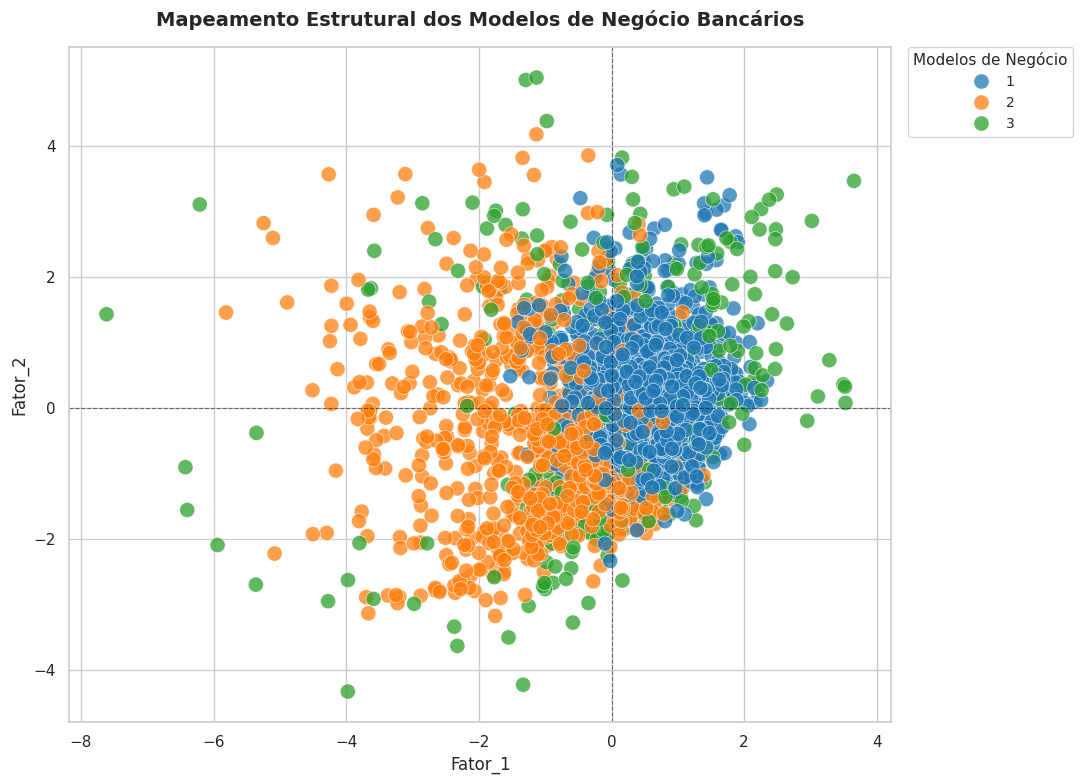

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

def plotar_clusters(coordenadas):
    # 1. Definir o estilo visual do gráfico
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(11, 8))

    # 2. Criar o gráfico de dispersão
    # O parâmetro 'hue' faz a mágica de colorir por cluster automaticamente
    grafico = sns.scatterplot(
        data=coordenadas,
        x='Fator_1',
        y='Fator_2',
        hue='Cluster',          # Coluna que define as cores
        palette='tab10',        # Paleta de cores distintas para variáveis categóricas
        alpha=0.75,             # Transparência para pontos sobrepostos
        s=120,                  # Tamanho dos pontos
        edgecolor='w',          # Contorno branco nos pontos para destacá-los
        linewidth=0.5
    )

    # 3. Adicionar linhas cruzadas no zero (eixos cartesianos)
    # Isso ajuda visualmente a dividir os 4 quadrantes dos modelos de negócio
    plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    plt.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

    # 4. Customizar os títulos e rótulos dos eixos com os significados econômicos
    plt.title('Mapeamento Estrutural dos Modelos de Negócio Bancários', fontsize=14, fontweight='bold', pad=15)
    #plt.xlabel('Fator 1: Tesouraria e Atacado (+) vs. Varejo Tradicional (-)', fontsize=11, labelpad=10)
    #plt.ylabel('Fator 2: Risco e Inadimplência (+) vs. Liquidez e Segurança (-)', fontsize=11, labelpad=10)

    # 5. Ajustar a legenda para que ela fique limpa e fora da área de plotagem
    plt.legend(
        title='Modelos de Negócio', 
        bbox_to_anchor=(1.02, 1), 
        loc='upper left', 
        borderaxespad=0,
        fontsize=10,
        title_fontsize=11
    )

    # 6. Otimizar o espaçamento para não cortar textos
    plt.tight_layout()

    # 7. Exibir o gráfico no Jupyter Notebook
    plt.show()

plotar_clusters(df_clusters_finais)

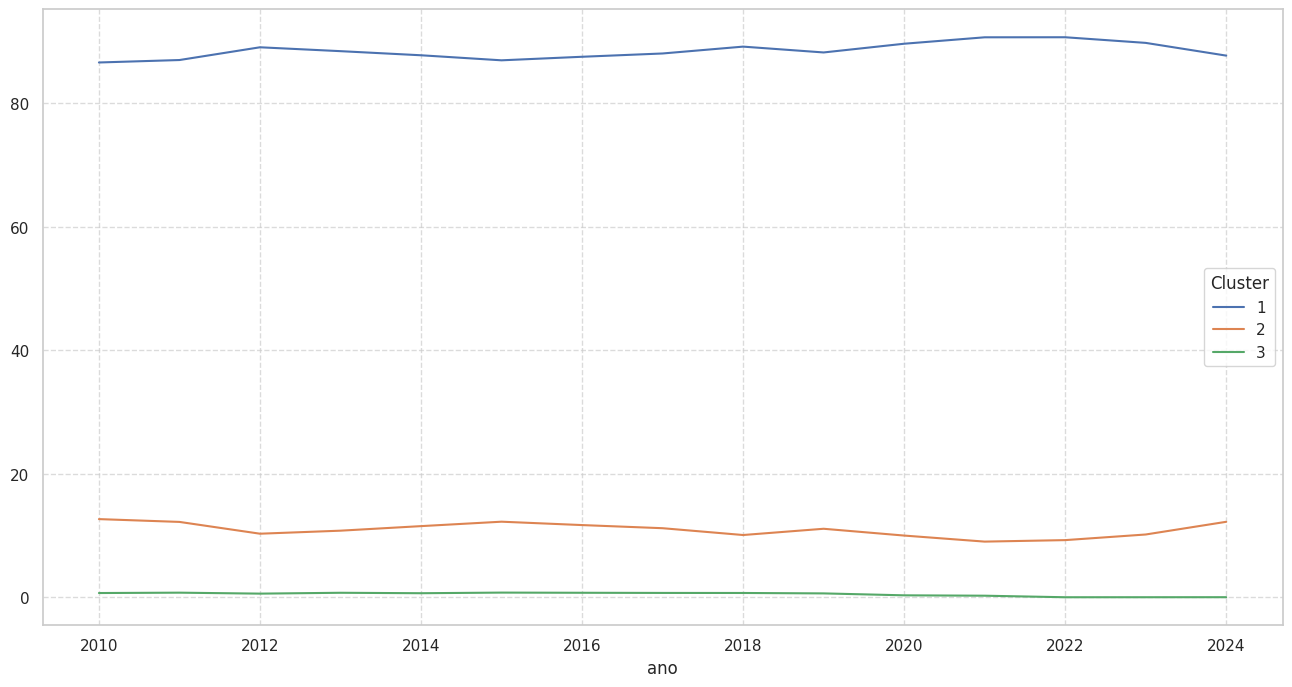

In [10]:
def calcular_market_share(df_original):
    share_individual = df_original.groupby(['ano', 'cnpj'])['ativo realizavel - operacoes de credito'].sum().reset_index()

    share_individual.columns = ['ano', 'cnpj', 'credito_cnpj']

    share_individual['market_share'] = (
        share_individual['credito_cnpj'] / 
        share_individual.groupby('ano')['credito_cnpj'].transform('sum')
    )

    share_individual = pd.merge(share_individual, df_original[['ano','cnpj', 'nome', 'taxonomia', 'Cluster']], on=['ano', 'cnpj'], how='left')

    coluna_c = share_individual.pop('market_share')
    share_individual.insert(6, 'market_share', coluna_c)
    coluna_c = share_individual.pop('credito_cnpj')
    share_individual.insert(6, 'credito_cnpj', coluna_c)

    # 1. Agrupar por ano e cluster para somar o crédito
    share_df = df_original.groupby(['ano', 'Cluster'])['ativo realizavel - operacoes de credito'].sum().reset_index()

    # Renomear para clareza
    share_df.columns = ['ano', 'Cluster', 'credito_cluster']

    # 2. Calcular o total do mercado para cada ano e dividir o valor do cluster por esse total
    share_df['market_share'] = (
        share_df['credito_cluster'] / 
        share_df.groupby('ano')['credito_cluster'].transform('sum')
    )

    # Converter para porcentagem para facilitar a leitura
    share_df['market_share_pct'] = share_df['market_share'] * 100

    tabela_share = share_df.pivot(index='Cluster', columns='ano', values='market_share_pct').fillna(0)

    tabela_share.T.plot(kind='line', stacked=False, marker='', alpha=1, figsize=(16,8))
    plt.grid(True, linestyle='--', alpha=0.7)
    return share_individual

share_individual = calcular_market_share(df_original)

In [11]:
# Dados de volatilidade de taxas de juros

def dados_juros():
    conn = sqlite3.connect('dados/banking.db')

    query = """
    SELECT
        *
    FROM
        media_volatilidade_anual
    """

    taxas_termo = pd.read_sql_query(query, conn)

    conn.close()

    taxas_termo['ano'] = taxas_termo['ano'].astype(int)
    return taxas_termo

taxas_termo = dados_juros()

variaveis_df_original = pd.DataFrame({'Contas': [col for col in df_original.columns]})

In [12]:

def criar_indicadores_modelo(df_original, share_individual, taxas_termo):
    model  = df_original[['ano', 'cnpj', 'nome', 'taxonomia','Cluster']].copy()

    # Net Interest Margin (nim)

    #model['nim'] = 100 * (df[['resultado credor - receitas operacionais', 'resultado devedor - (-) despesas de captacao']].sum(axis=1) / df_original['ativo realizavel - ativo realizavel'])

    model['nim'] = 100 * (df_original['resultado credor - rendas de operacoes de credito'] + df_original['resultado credor - rendas com titulos e valores mobiliarios e instrumentos financeiros derivativos'] - df_original['resultado devedor - (-) despesas de captacao'].abs()) / df_original['ativo realizavel - ativo realizavel']

    # Herfindal (herf)

    share_individual['share_quadrado'] = share_individual['market_share'] ** 2
    hhi_anual = share_individual.groupby('ano')['share_quadrado'].sum().reset_index()
    hhi_anual.columns = ['ano', 'hhi']
    model = model.reset_index()

    model = pd.merge(
        model,
        hhi_anual,
        on=['ano'],
        how='left'
    )
    model = model.set_index('index')
    model.index.name = None
    model['hhi'] = model['hhi']

    # Operating Costs (aoc)

    model['aoc'] = 100 * (df_original['resultado devedor - (-) despesas operacionais'].abs() / df_original['compensacao ativa - total geral do ativo'])

    # Degree of risk aversion (riskaver)

    model['riskaver'] = 100 * (df_original['patrimonio liquido - patrimonio liquido'] / df_original['compensacao ativa - total geral do ativo'])

    # Volatility of market interest rates (sd*)

    model = model.reset_index()
    model = pd.merge(
        model,
        taxas_termo,
        on=['ano'],
        how='left'
    )
    model = model.set_index('index')
    model.index.name = None

    # Credit Risk (crerisk)

    model['crerisk'] = 100 * (df_original['ativo realizavel - (-) provisoes para operacoes de credito'].abs() / df_original['ativo realizavel - operacoes de credito'])

    # Interaction between credit risk and market risk (sd*crerisk)

    model['sd_3m*crerisk'] = model['sd_annual_3m'] * model['crerisk'] / 100
    model['sd_1ano*crerisk'] = model['sd_annual_1ano'] * model['crerisk'] / 100
    model['sd_2anos*crerisk'] = model['sd_annual_2anos'] * model['crerisk'] / 100
    model['sd_3anos*crerisk'] = model['sd_annual_3anos'] * model['crerisk'] / 100
    model['sd_5anos*crerisk'] = model['sd_annual_5anos'] * model['crerisk'] / 100

    # Average size of operations/volume of loans (size)

    model['size'] = np.log(df_original['ativo realizavel - operacoes de credito'])

    # Implicit interest payments (iip)

    model['iip'] = 100 * ((df_original['resultado devedor - (-) despesas operacionais'].abs() - df_original['resultado credor - rendas de prestacao de servicos']) / df_original['compensacao ativa - total geral do ativo'])

    # Opportunity costs of bank reserves (reser)

    model['reser'] = 100 * (df_original[['ativo realizavel - disponibilidades', 'ativo realizavel - aplicacoes interfinanceiras de liquidez']].sum(axis=1) / df_original['compensacao ativa - total geral do ativo'])

    #model['reser'] = 100 * ((df_original['ativo realizavel - disponibilidades'] + df_original['ativo realizavel - aplicacoes interfinanceiras de liquidez']) / df_original['compensacao ativa - total geral do ativo'])

    # Quality of management (ef)

    model['ef'] = 100 * (df_original['resultado devedor - (-) despesas operacionais'].abs() / df_original['resultado credor - receitas operacionais'])

    # Time dummies
    dummies_tempo = pd.get_dummies(model['ano'], drop_first=True)
    dummies_tempo = dummies_tempo.astype(int)
    model = pd.concat([model, dummies_tempo], axis=1)
    return model



model = criar_indicadores_modelo(df_original, share_individual, taxas_termo)

In [13]:
# Market Structure (lerner)

import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects

def estimar_indice_lerner(model, df_original):
    model['Price'] = (df_original['resultado credor - receitas operacionais'] + df_original['resultado credor - receitas nao operacionais']) / df_original['compensacao ativa - total geral do ativo']

    model['C'] = df_original['resultado devedor - (-) despesas de captacao'] + df_original['resultado devedor - (-) despesas administrativas']

    model['ativo_total'] = df_original['compensacao ativa - total geral do ativo']

    model['w1'] = 100* df_original['resultado devedor - (-) despesas administrativas'] / df_original['compensacao ativa - total geral do ativo']

    model['w2'] = (df_original['resultado devedor - (-) despesas operacionais'] - df_original['resultado devedor - (-) despesas administrativas']) / (df_original['ativo permanente - permanente'] - df_original['ativo permanente - ativos intangiveis'] - df_original['ativo permanente - investimentos'])

    model['w3'] = (df_original['resultado devedor - (-) despesas de captacao'] + df_original['resultado devedor - (-) despesas de obrigacoes por emprestimos e repasses'] + df_original['resultado devedor - (-) despesas com titulos e valores mobiliarios    e instrumentos financeiros derivativos'] + df_original['resultado devedor - (-) aprovisionamentos e ajustes patrimoniais']) / df_original['passivo exigivel - depositos']

    # ========================================================
    # Normalização (Homogeneidade de Grau 1)
    # Dividimos C, w1 e w2 pelo w3
    # ========================================================
    model['C_norm']  = model['C'] / model['w3']
    model['w1_norm'] = model['w1'] / model['w3']
    model['w2_norm'] = model['w2'] / model['w3']

    # ========================================================
    # Transformações Logarítmicas e Termos Quadráticos (Translog)
    # ========================================================
    # Evitar log de zero (adicionando um valor minúsculo)
    epsilon = 1e-10

    model['ln_C']  = np.log(model['C_norm'] + epsilon)
    model['ln_TA'] = np.log(model['ativo_total'] + epsilon)
    model['ln_w1'] = np.log(model['w1_norm'] + epsilon)
    model['ln_w2'] = np.log(model['w2_norm'] + epsilon)

    # Quadrados (já multiplicados por 0.5 conforme a fórmula do artigo)
    model['ln_TA_sq'] = 0.5 * (model['ln_TA'] ** 2)
    model['ln_w1_sq'] = 0.5 * (model['ln_w1'] ** 2)
    model['ln_w2_sq'] = 0.5 * (model['ln_w2'] ** 2)

    # Interações
    model['ln_w1_w2'] = model['ln_w1'] * model['ln_w2']
    model['ln_TA_w1'] = model['ln_TA'] * model['ln_w1']
    model['ln_TA_w2'] = model['ln_TA'] * model['ln_w2']

    # Variável de Tendência Tecnológica (Trend)
    #model.set_index('ano', inplace=True)
    ano_minimo = model['ano'].min()
    model['Trend'] = model['ano'] - ano_minimo + 1
    model['Trend_sq'] = 0.5 * (model['Trend'] ** 2)
    model['Trend_ln_TA'] = model['Trend'] * model['ln_TA']

    # Limpar Nulos e Infinitos antes da regressão
    cols_reg = ['ln_C', 'ln_TA', 'ln_TA_sq', 'ln_w1', 'ln_w2', 'ln_w1_sq', 'ln_w2_sq', 'ln_w1_w2', 'ln_TA_w1', 'ln_TA_w2', 'Trend', 'Trend_sq', 'Trend_ln_TA']
    model = model.replace([np.inf, -np.inf], np.nan).dropna(subset=cols_reg)
    df_panel = model.set_index(['cnpj', 'ano'])

    # ========================================================
    # Regressão de Efeitos Fixos (Within-Group)
    # ========================================================
    X_cols = cols_reg[1:] # Todas as colunas exceto ln_C
    X = sm.add_constant(df_panel[X_cols])
    Y = df_panel['ln_C']

    # entity_effects=True garante que cada banco tenha seu intercepto próprio
    modelo = PanelOLS(Y, X, entity_effects=True)
    resultados = modelo.fit(cov_type='clustered', cluster_entity=True)
    print("=== Resultado da Função de Custo Translog ===")
    print(resultados.summary)

    # ========================================================
    # Calcular o Custo Marginal e o Índice de Lerner
    # ========================================================
    # Resgatando os coeficientes da regressão
    alpha_1 = resultados.params['ln_TA']
    alpha_2 = resultados.params['ln_TA_sq']
    gamma_1 = resultados.params['ln_TA_w1']
    gamma_2 = resultados.params['ln_TA_w2']
    mu_3    = resultados.params['Trend_ln_TA']

    # 1. Elasticidade do Custo em relação ao Ativo (d ln C / d ln TA)
    df_panel['elasticidade_custo'] = (alpha_1 + 
                                    alpha_2 * df_panel['ln_TA'] + 
                                    gamma_1 * df_panel['ln_w1'] + 
                                    gamma_2 * df_panel['ln_w2'] + 
                                    mu_3 * df_panel['Trend'])

    # 2. Custo Marginal (MC)
    df_panel['MC'] = (df_panel['C'] / df_panel['ativo_total']) * df_panel['elasticidade_custo']

    # 3. Preço do Produto (Receitas Totais / Ativo Total)
    #df_panel['Price'] = (df_panel['receitas_operacionais'] + df_panel['receitas_financeiras']) / df_panel['ativo_total']

    # 4. Índice de Lerner
    df_panel['Lerner'] = (df_panel['Price'] - df_panel['MC']) / df_panel['Price']
    df_panel.reset_index(inplace=True)
    
    return df_panel, resultados

#model_lerner, resultados_lerner = variaveis_lerner(model, df_original)
model_lerner, resultados_lerner = estimar_indice_lerner(model, df_original)

=== Resultado da Função de Custo Translog ===
                          PanelOLS Estimation Summary                           
Dep. Variable:                   ln_C   R-squared:                        0.9982
Estimator:                   PanelOLS   R-squared (Between):              0.9990
No. Observations:                2586   R-squared (Within):               0.9982
Date:                Wed, Jun 17 2026   R-squared (Overall):              0.9983
Time:                        18:11:49   Log-likelihood                   -706.15
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   1.033e+05
Entities:                         278   P-value                           0.0000
Avg Obs:                       9.3022   Distribution:                 F(12,2296)
Min Obs:                       1.0000                                           
Max Obs:                       15.000   F-statistic (robust):  

In [14]:
import plotly.express as px

# Supondo que o seu dataframe final com os cálculos se chame 'df_com_lerner'
# E que ele tenha as colunas: 'Cluster', 'elasticidade_custo', 'Lerner', 'MC' (Custo Marginal) e 'Nome_Banco'
def plotar_bubble_chart(df_com_lerner, ano):
    df_plot = df_com_lerner[df_com_lerner['Cluster'] != 4]
    #df_plot = df_plot[df_plot['Cluster'] != 1]
    # 1. Preparar os dados (remover NAs para o gráfico não quebrar)
    if ano > 0:
        df_plot = df_plot[df_plot['ano'] == ano]
    
    df_plot = df_plot.dropna(subset=['elasticidade_custo', 'Lerner', 'MC']).copy()

    # Garantir que o Cluster seja tratado como categoria (texto) para cores distintas
    df_plot['Cluster'] = df_plot['Cluster'].astype(str)

    # 2. Criar o Gráfico de Dispersão de Bolhas (Bubble Chart)
    fig = px.scatter(
        df_plot,
        x="elasticidade_custo",         # Eixo X
        y="Lerner",                     # Eixo Y
        #size="ativo_total",                      # Tamanho da bolha (Pode trocar por 'ativo_total' se preferir)
        color="Cluster",                # Uma cor para cada modelo de negócios
        hover_name="nome",        # O nome que aparece em destaque ao passar o mouse
        hover_data={                    # Dados extras no tooltip
            "elasticidade_custo": ':.3f', 
            "Lerner": ':.3f',
            "MC": ':.4f',
            "Cluster": False            # Oculta o cluster do tooltip, pois já está na cor
        },
        opacity=0.6,                    # SOLUÇÃO 1: Transparência de 60%
        #size_max=18,                    # SOLUÇÃO 3: Reduzindo o limite de tamanho
        range_x=[0.75, 1.5],          # Limita o Eixo X (Elasticidade)
        range_y=[-0.25, 1.1],         # Limita o Eixo Y (Lerner). Coloquei 1.1 como teto lógico
        title="Microeconomia dos Clusters: Poder de Mercado vs. Economias de Escala",
        labels={
            "elasticidade_custo": "Elasticidade de Custo (Escala)",
            "Lerner": "Índice de Lerner (Poder de Precificação)",
            "MC": "Custo Marginal"
        },
        template="plotly_white"         # Fundo limpo e acadêmico
    )

    # 3. Adicionar as Linhas de Referência Estruturais (Cruciais para a análise)
    # Linha Vertical: Separa Economias de Escala (< 1) de Deseconomias (> 1)
    fig.add_vline(
        x=1.0, 
        line_dash="dash", 
        line_color="gray", 
        annotation_text="Retornos Constantes (E = 1)", 
        annotation_position="top right"
    )

    # Linha Horizontal: Separa Poder de Monopólio (> 0) de Preço Predatório (< 0)
    fig.add_hline(
        y=0.0, 
        line_dash="dash", 
        line_color="gray", 
        annotation_text="Concorrência Perfeita (L = 0)", 
        annotation_position="bottom right"
    )

    # 4. Centralizar o título e exibir
    fig.update_layout(title_x=0.5)
    fig.show()

    # Para salvar como uma página interativa separada (opcional):
    # fig.write_html("analise_clusters_microeconomia.html")

plotar_bubble_chart(model_lerner, ano=2015) # ano=0 para mostrar todos os anos juntos, ou coloque um ano específico

=== Correlação (Pearson) entre Poder de Mercado (Lerner) e Risco (crerisk) ===
 Cluster  Correlacao
       2    0.126244
       3    0.056722
       1   -0.085360

------------------------------------------------------------



/tmp/ipykernel_675367/2632967047.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlacoes = df_corr.groupby('Cluster').apply(
/home/hspassos/anaconda3/envs/bcb/lib/python3.12/site-packages/seaborn/regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/home/hspassos/anaconda3/envs/bcb/lib/python3.12/site-packages/seaborn/regression.py:598: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


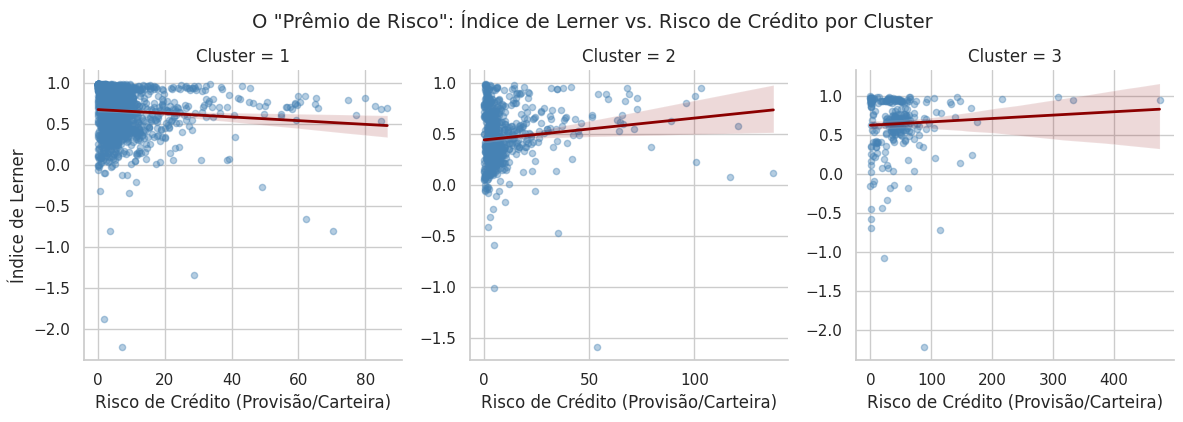

In [15]:

def analisar_correlacao_lerner_risco(model_lerner):
    df_corr = model_lerner.dropna(subset=['Lerner', 'crerisk', 'Cluster']).copy()

    # 2. A Tabela Matemática: Correlação de Pearson por Cluster
    print("=== Correlação (Pearson) entre Poder de Mercado (Lerner) e Risco (crerisk) ===")
    correlacoes = df_corr.groupby('Cluster').apply(
        lambda x: x['Lerner'].corr(x['crerisk'])
    ).reset_index(name='Correlacao')

    # Ordenar para ver quem tem a maior correlação
    correlacoes = correlacoes.sort_values(by='Correlacao', ascending=False)
    print(correlacoes.to_string(index=False))
    print("\n" + "-"*60 + "\n")

    # 3. A Prova Visual: Gráficos de Dispersão com Linha de Tendência
    # Configura o estilo acadêmico
    sns.set_theme(style="whitegrid")

    # Cria um painel com um gráfico para cada cluster
    g = sns.lmplot(
        data=df_corr,
        x='crerisk',                 # Eixo X: Risco de Crédito (Custo do Calote)
        y='Lerner',                  # Eixo Y: Índice de Lerner (Margem Bruta)
        col='Cluster',               # Divide em painéis por Cluster
        col_wrap=3,                  # Quantos gráficos por linha
        height=4,
        sharex=False,                # Deixa o eixo X livre (riscos variam muito)
        sharey=False,                # Deixa o eixo Y livre
        scatter_kws={'alpha': 0.4, 'color': 'steelblue', 's': 20}, # Bolhas transparentes
        line_kws={'color': 'darkred', 'linewidth': 2}              # Linha de tendência vermelha
    )

    # Ajuste do título principal
    g.fig.suptitle('O "Prêmio de Risco": Índice de Lerner vs. Risco de Crédito por Cluster', y=1.05, fontsize=14)
    g.set_axis_labels("Risco de Crédito (Provisão/Carteira)", "Índice de Lerner")

    plt.show()

analisar_correlacao_lerner_risco(model_lerner)

In [17]:
def rodar_regressao_efeitos_aleatorios(df):
    df = df.set_index(['cnpj', 'ano'])
    # Transformar a coluna de clusters em Variáveis Dummy (0 ou 1)
    dummies_cluster = pd.get_dummies(df['Cluster'], prefix='Cluster', dtype=int)

    # Juntamos essas dummies de volta ao nosso painel principal
    df = pd.concat([df, dummies_cluster], axis=1)
    
    # 2. Variáveis do modelo (Atenção ao nome da variável da Selic: sd_annual_3m)
    vars_modelo = ['nim', 'Lerner', 'aoc', 'riskaver', 'crerisk', 'sd_annual_3m', 'ef', 'size', 'iip', 'reser']
    
    # Clusters mantidos (Cluster 1, os pequenos, ficam de fora como Categoria Base)
    vars_clusters = ['Cluster_1', 'Cluster_2'] 
    
    # 3. Criando as interações (Lerner x Cluster)
    for c in vars_clusters:
        df[f'Lerner_x_{c}'] = df['Lerner'] * df[c]
        
    vars_interacao = [f'Lerner_x_{c}' for c in vars_clusters]
    
    # 4. Limpeza de NAs e Separação de X e Y
    cols_necessarias = vars_modelo + vars_clusters + vars_interacao
    df_reg = df.dropna(subset=cols_necessarias).copy()
    
    Y = df_reg['nim']
    X = df_reg[['Lerner', 'aoc', 'riskaver', 'crerisk', 'sd_annual_3m', 'sd_annual_1ano', 'ef', 'size', 'iip', 'reser'] + 
               vars_clusters + vars_interacao]
    
    X = sm.add_constant(X)
    
    # 5. Estimar o Modelo com Efeitos Aleatórios
    # O RandomEffects lida com a estrutura de painel sem criar dummies rígidas para cada banco
    modelo_re = RandomEffects(Y, X)
    
    # Erros robustos clusterizados por instituição
    resultados_re = modelo_re.fit(cov_type='clustered', cluster_entity=True)
    
    print("=== Determinantes da Margem de Juros (NIM) - EFEITOS ALEATÓRIOS ===")
    print(resultados_re.summary)
    
    return resultados_re

# Executar a regressão
resultados_nim_re = rodar_regressao_efeitos_aleatorios(model_lerner)

=== Determinantes da Margem de Juros (NIM) - EFEITOS ALEATÓRIOS ===
                        RandomEffects Estimation Summary                        
Dep. Variable:                    nim   R-squared:                        0.2791
Estimator:              RandomEffects   R-squared (Between):             -2.5048
No. Observations:                2586   R-squared (Within):               0.4163
Date:                Wed, Jun 17 2026   R-squared (Overall):              0.0537
Time:                        18:12:10   Log-likelihood                   -9677.0
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      71.108
Entities:                         278   P-value                           0.0000
Avg Obs:                       9.3022   Distribution:                 F(14,2571)
Min Obs:                       1.0000                                           
Max Obs:                       15.000   F